# 04 - Order effect and the rhyme hypothesis (paper Fig 9, Section 6)

Because Moravec draws operands independently each trial, the same
unordered pair (e.g. {4, 7}) gets shown sometimes as 4x7 and sometimes as
7x4. This lets us compare RT by presentation order for each individual
problem -- the paper's headline new result, and the rhyme-effect test
(problems that rhyme in Spanish when spoken max-operand-first are answered
faster in that order).


In [1]:
# Data source toggle. The live backend DB has zero trial_results as of
# 2026-09 (see ../DATA_GAPS.md) -- this app just went public. Flip
# USE_SYNTHETIC to False once real rows exist; every cell below is written
# against the DataFrame shape returned by moravec_analysis.data, so nothing
# else needs to change.
USE_SYNTHETIC = False

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from moravec_analysis.data import load_trial_results
from moravec_analysis.features import add_all_derived_fields, filter_rt_outliers
from moravec_analysis.synth import generate_synthetic_trials

if USE_SYNTHETIC:
    raw = generate_synthetic_trials(n_users=400, trials_per_user=150, seed=7)
else:
    raw = load_trial_results()  # defaults to apps/backend/data/moravec.sqlite

df = add_all_derived_fields(raw)
print(f"{len(df):,} trials, {df.email_hash.nunique():,} users")
df.head()


410 trials, 1 users


,id,email_hash,level_number,category_codename,operands,answer,correct,time_exceeded,time_taken,played_at,...,has_five,op1_gt_op2,unordered_pair,presented_pair,is_rhyme_pair,presented_in_rhyme_order,is_rhyme_control_pair,presented_in_control_order,table_distance_1,numeric_distance_le_2
0,b71489e4-4089-48fb-91c8-57018effab49,1bb8091170824093896f3bb9d158991b637d108c9b11ff...,1,1d+1d,"[5, 3]",8,True,False,1376,2026-09-02 14:20:30.456,...,True,True,"(3, 5)","(5, 3)",False,False,True,False,<NA>,<NA>
1,ff1c2b76-e8c9-4244-81d7-0bc393f456fa,1bb8091170824093896f3bb9d158991b637d108c9b11ff...,1,1d+1d,"[4, 6]",10,True,False,1384,2026-09-02 14:20:31.840,...,False,False,"(4, 6)","(4, 6)",True,False,False,False,<NA>,<NA>
2,e69af72d-ab35-434f-8cc6-083e1554cd64,1bb8091170824093896f3bb9d158991b637d108c9b11ff...,1,1d+1d,"[8, 5]",13,True,False,1581,2026-09-02 14:20:33.421,...,True,True,"(5, 8)","(8, 5)",False,False,False,False,<NA>,<NA>
3,e027f4db-5f97-4e4c-af89-ee8028b725cf,1bb8091170824093896f3bb9d158991b637d108c9b11ff...,1,1dx1d,"[9, 4]",36,True,False,2145,2026-09-02 14:20:35.566,...,False,True,"(4, 9)","(9, 4)",False,False,False,False,<NA>,<NA>
4,12772bbc-689d-4107-bb36-0092ee87088a,1bb8091170824093896f3bb9d158991b637d108c9b11ff...,1,1dx1d,"[7, 7]",49,True,False,1259,2026-09-02 14:20:36.825,...,False,False,"(7, 7)","(7, 7)",False,False,False,False,<NA>,<NA>


In [2]:
one_by_one = df[df["category_codename"].isin(["1d+1d", "1dx1d"]) & df["correct"]]
clean = filter_rt_outliers(one_by_one, group_col="category_codename", sd=4.0)
mult = clean[(clean["category_codename"] == "1dx1d") & (~clean["is_tie"])]
add = clean[(clean["category_codename"] == "1d+1d") & (~clean["is_tie"])]


## Per-problem order effect (paper Fig 9)

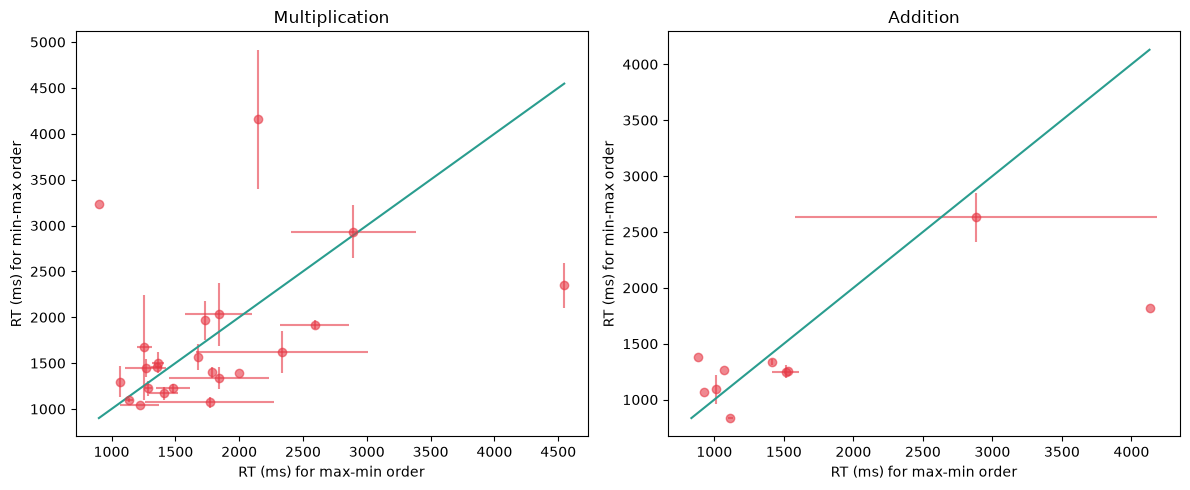

In [3]:
def per_problem_order_rt(data):
    return (
        data.groupby(["unordered_pair", "op1_gt_op2"])["time_taken"]
        .agg(["mean", "sem", "count"])
        .unstack("op1_gt_op2")
    )


def plot_order_effect(data, title, ax):
    pivot = per_problem_order_rt(data)
    max_first = pivot["mean"][True]
    min_first = pivot["mean"][False]
    ax.errorbar(
        max_first, min_first,
        xerr=pivot["sem"][True], yerr=pivot["sem"][False],
        fmt="o", color="#e63946", ecolor="#e63946", alpha=0.6,
    )
    lims = [min(max_first.min(), min_first.min()), max(max_first.max(), min_first.max())]
    ax.plot(lims, lims, "-", color="#2a9d8f")
    ax.set_xlabel("RT (ms) for max-min order")
    ax.set_ylabel("RT (ms) for min-max order")
    ax.set_title(title)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_order_effect(mult, "Multiplication", axes[0])
plot_order_effect(add, "Addition", axes[1])
plt.tight_layout()
plt.show()


Points above the diagonal are faster in max-min order (the paper's main finding: 7x4 faster than 4x7). Run a mixed model with `op1_gt_op2` as fixed effect per problem/table to get the significance the paper reports via likelihood-ratio tests.

In [4]:
import statsmodels.formula.api as smf

def order_effect_overall(data, label):
    sub = data.copy()
    sub["op1_gt_op2"] = sub["op1_gt_op2"].astype(int)
    model = smf.mixedlm("time_taken ~ op1_gt_op2", data=sub, groups=sub["email_hash"])
    result = model.fit(reml=False)
    print(f"=== {label}: overall max-first effect ===")
    print(result.summary().tables[1].loc[["op1_gt_op2"]])
    print()


order_effect_overall(mult, "Multiplication")
order_effect_overall(add, "Addition")


/home/juancuiule/eglc-moravec/packages/analysis/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2384: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  rslt = super().fit(
/tmp/ipykernel_871653/1223280556.py:7: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  result = model.fit(reml=False)
/home/juancuiule/eglc-moravec/packages/analysis/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:589: SingularMatrixWarning: Random effects covariance is singular
  return -self.score(params, *args) / nobs
/home/juancuiule/eglc-moravec/packages/analysis/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2429: SingularMatrixWarning: The random effects covariance matrix is singular.
  scale = self.get_scale(fe_params, cov_re_unscaled, vcomp_unscaled)
/tmp/ipykernel_871653/1223280556.py:7: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  result = mo

=== Multiplication: overall max-first effect ===
              Coef. Std.Err.      z  P>|z|   [0.025   0.975]
op1_gt_op2  222.472  150.086  1.482  0.138  -71.691  516.635



/home/juancuiule/eglc-moravec/packages/analysis/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2384: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  rslt = super().fit(
/tmp/ipykernel_871653/1223280556.py:7: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  result = model.fit(reml=False)
/home/juancuiule/eglc-moravec/packages/analysis/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:589: SingularMatrixWarning: Random effects covariance is singular
  return -self.score(params, *args) / nobs
/home/juancuiule/eglc-moravec/packages/analysis/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:589: SingularMatrixWarning: Random effects covariance is singular
  return -self.score(params, *args) / nobs
/home/juancuiule/eglc-moravec/packages/analysis/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:589: SingularMatrixWarning: Random effects covariance is singular
  return -

=== Addition: overall max-first effect ===
              Coef. Std.Err.      z  P>|z|    [0.025   0.975]
op1_gt_op2  129.490  212.241  0.610  0.542  -286.494  545.475



## Rhyme effect (the 4 problems: 6x4, 7x5, 9x5, 6x8)

In [5]:
rhyme = mult[mult["is_rhyme_pair"]].copy()
rhyme["presented_in_rhyme_order"] = rhyme["presented_in_rhyme_order"].astype(int)

model = smf.mixedlm(
    "time_taken ~ presented_in_rhyme_order",
    data=rhyme,
    groups=rhyme["email_hash"],
)
print(model.fit(reml=False).summary().tables[1])


                             Coef.        Std.Err.       z  P>|z|  \
Intercept                 -246.816  2378601807.242  -0.000  1.000   
presented_in_rhyme_order  -232.878         100.390  -2.320  0.020   
Group Var                    0.000                                  

                                   [0.025          0.975]  
Intercept                 -4661974122.572  4661973628.940  
presented_in_rhyme_order         -429.638         -36.118  
Group Var                                                  


/home/juancuiule/eglc-moravec/packages/analysis/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2384: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  rslt = super().fit(
/tmp/ipykernel_871653/1222259257.py:9: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  print(model.fit(reml=False).summary().tables[1])
/home/juancuiule/eglc-moravec/packages/analysis/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:589: SingularMatrixWarning: Random effects covariance is singular
  return -self.score(params, *args) / nobs
/home/juancuiule/eglc-moravec/packages/analysis/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2429: SingularMatrixWarning: The random effects covariance matrix is singular.
  scale = self.get_scale(fe_params, cov_re_unscaled, vcomp_unscaled)
/tmp/ipykernel_871653/1222259257.py:9: ConvergenceWarning: The MLE may be on the boundary of the parameter sp

Paper's prediction: `presented_in_rhyme_order` should have a significant negative coefficient (rhymed order is faster), and the effect should be *larger* for these 4 pairs than the general max-first order effect above -- the phonological hypothesis, not just the size/order effect.